# ⚡ Step 1: Install & Import

In [ ]:
!pip install -q timm pytorch-grad-cam

import os, sys, time, random, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader, random_split
from tqdm.notebook import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam
Using device: cuda
GPU: Tesla T4


# ✅ Step 2: Config & Data

In [ ]:
from tqdm.notebook import tqdm
import time, random
from pathlib import Path

# —— Config ————————————————————————————————————
IMG_SIZE    = 224  # EfficientNet pretrained on 224×224
BATCH_SIZE  = 128
EPOCHS      = 20   # 20 epochs is plenty with pretrained weights
LR_HEAD     = 1e-3  # Classifier head LR
LR_BACKBONE = 1e-4  # Backbone fine-tune LR (lower)
NUM_CLASSES = 10
SEED        = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# —— EfficientNet ImageNet normalization ——————————
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

# —— Transforms ————————————————————————————————
# NOTE: Upsample CIFAR-10 (32×32) → 224×224 for EfficientNet
train_transform = T.Compose([
    T.Resize(256),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(0.5),
    T.RandAugment(num_ops=2, magnitude=7),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.2)
])

test_transform = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

# —— Download CIFAR-10 (auto, in-memory) ——————————
print('Downloading CIFAR-10...')
train_full   = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=test_transform)

train_ds, val_ds = random_split(
    train_full, [45000, 5000],
    generator=torch.Generator().manual_seed(SEED)
)
# Val should use test_transform (no augmentation)
val_ds.dataset.transform = test_transform

train_loader = DataLoader(train_ds,     batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,       batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'  CIFAR-10 ready — no disk I/O overhead!')
print(f'  Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_dataset):,}')
print(f'  Image size fed to model: 224×224 (upscaled)')

100%|██████████| 170M/170M [00:03<00:00, 48.2MB/s]


  CIFAR-10 ready — no disk I/O overhead!
  Train: 45,000 | Val: 5,000 | Test: 10,000
  Image size fed to model: 224×224 (upscaled)


# 📊 Step 3: EDA

/tmp/ipykernel_950/3458180698.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(CLASS_NAMES, rotation=30, ha='right')


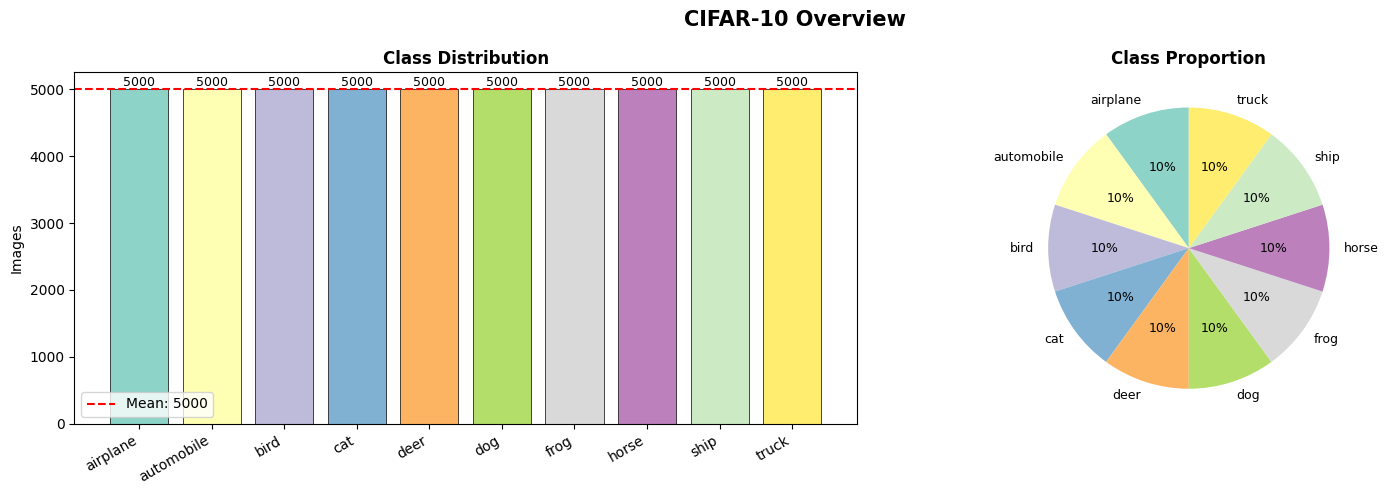

Dataset is perfectly balanced   


In [ ]:
from PIL import Image

raw_ds = torchvision.datasets.CIFAR10('./data', train=True, download=False, transform=T.ToTensor())
labels_all = np.array(raw_ds.targets)
counts = np.bincount(labels_all)
colors = plt.cm.Set3(np.linspace(0,1,10))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('CIFAR-10 Overview', fontsize=15, fontweight='bold')

bars = axes[0].bar(CLASS_NAMES, counts, color=colors, edgecolor='black', lw=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
axes[0].set_ylabel('Images')
axes[0].axhline(counts.mean(), color='red', ls='--', label=f'Mean: {counts.mean():.0f}')
axes[0].legend()
for bar, c in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, str(c), ha='center', fontsize=9)

axes[1].pie(counts, labels=CLASS_NAMES, colors=colors, autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 9})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/eda_distribution.png', dpi=150)
plt.show()
print('Dataset is perfectly balanced   ')

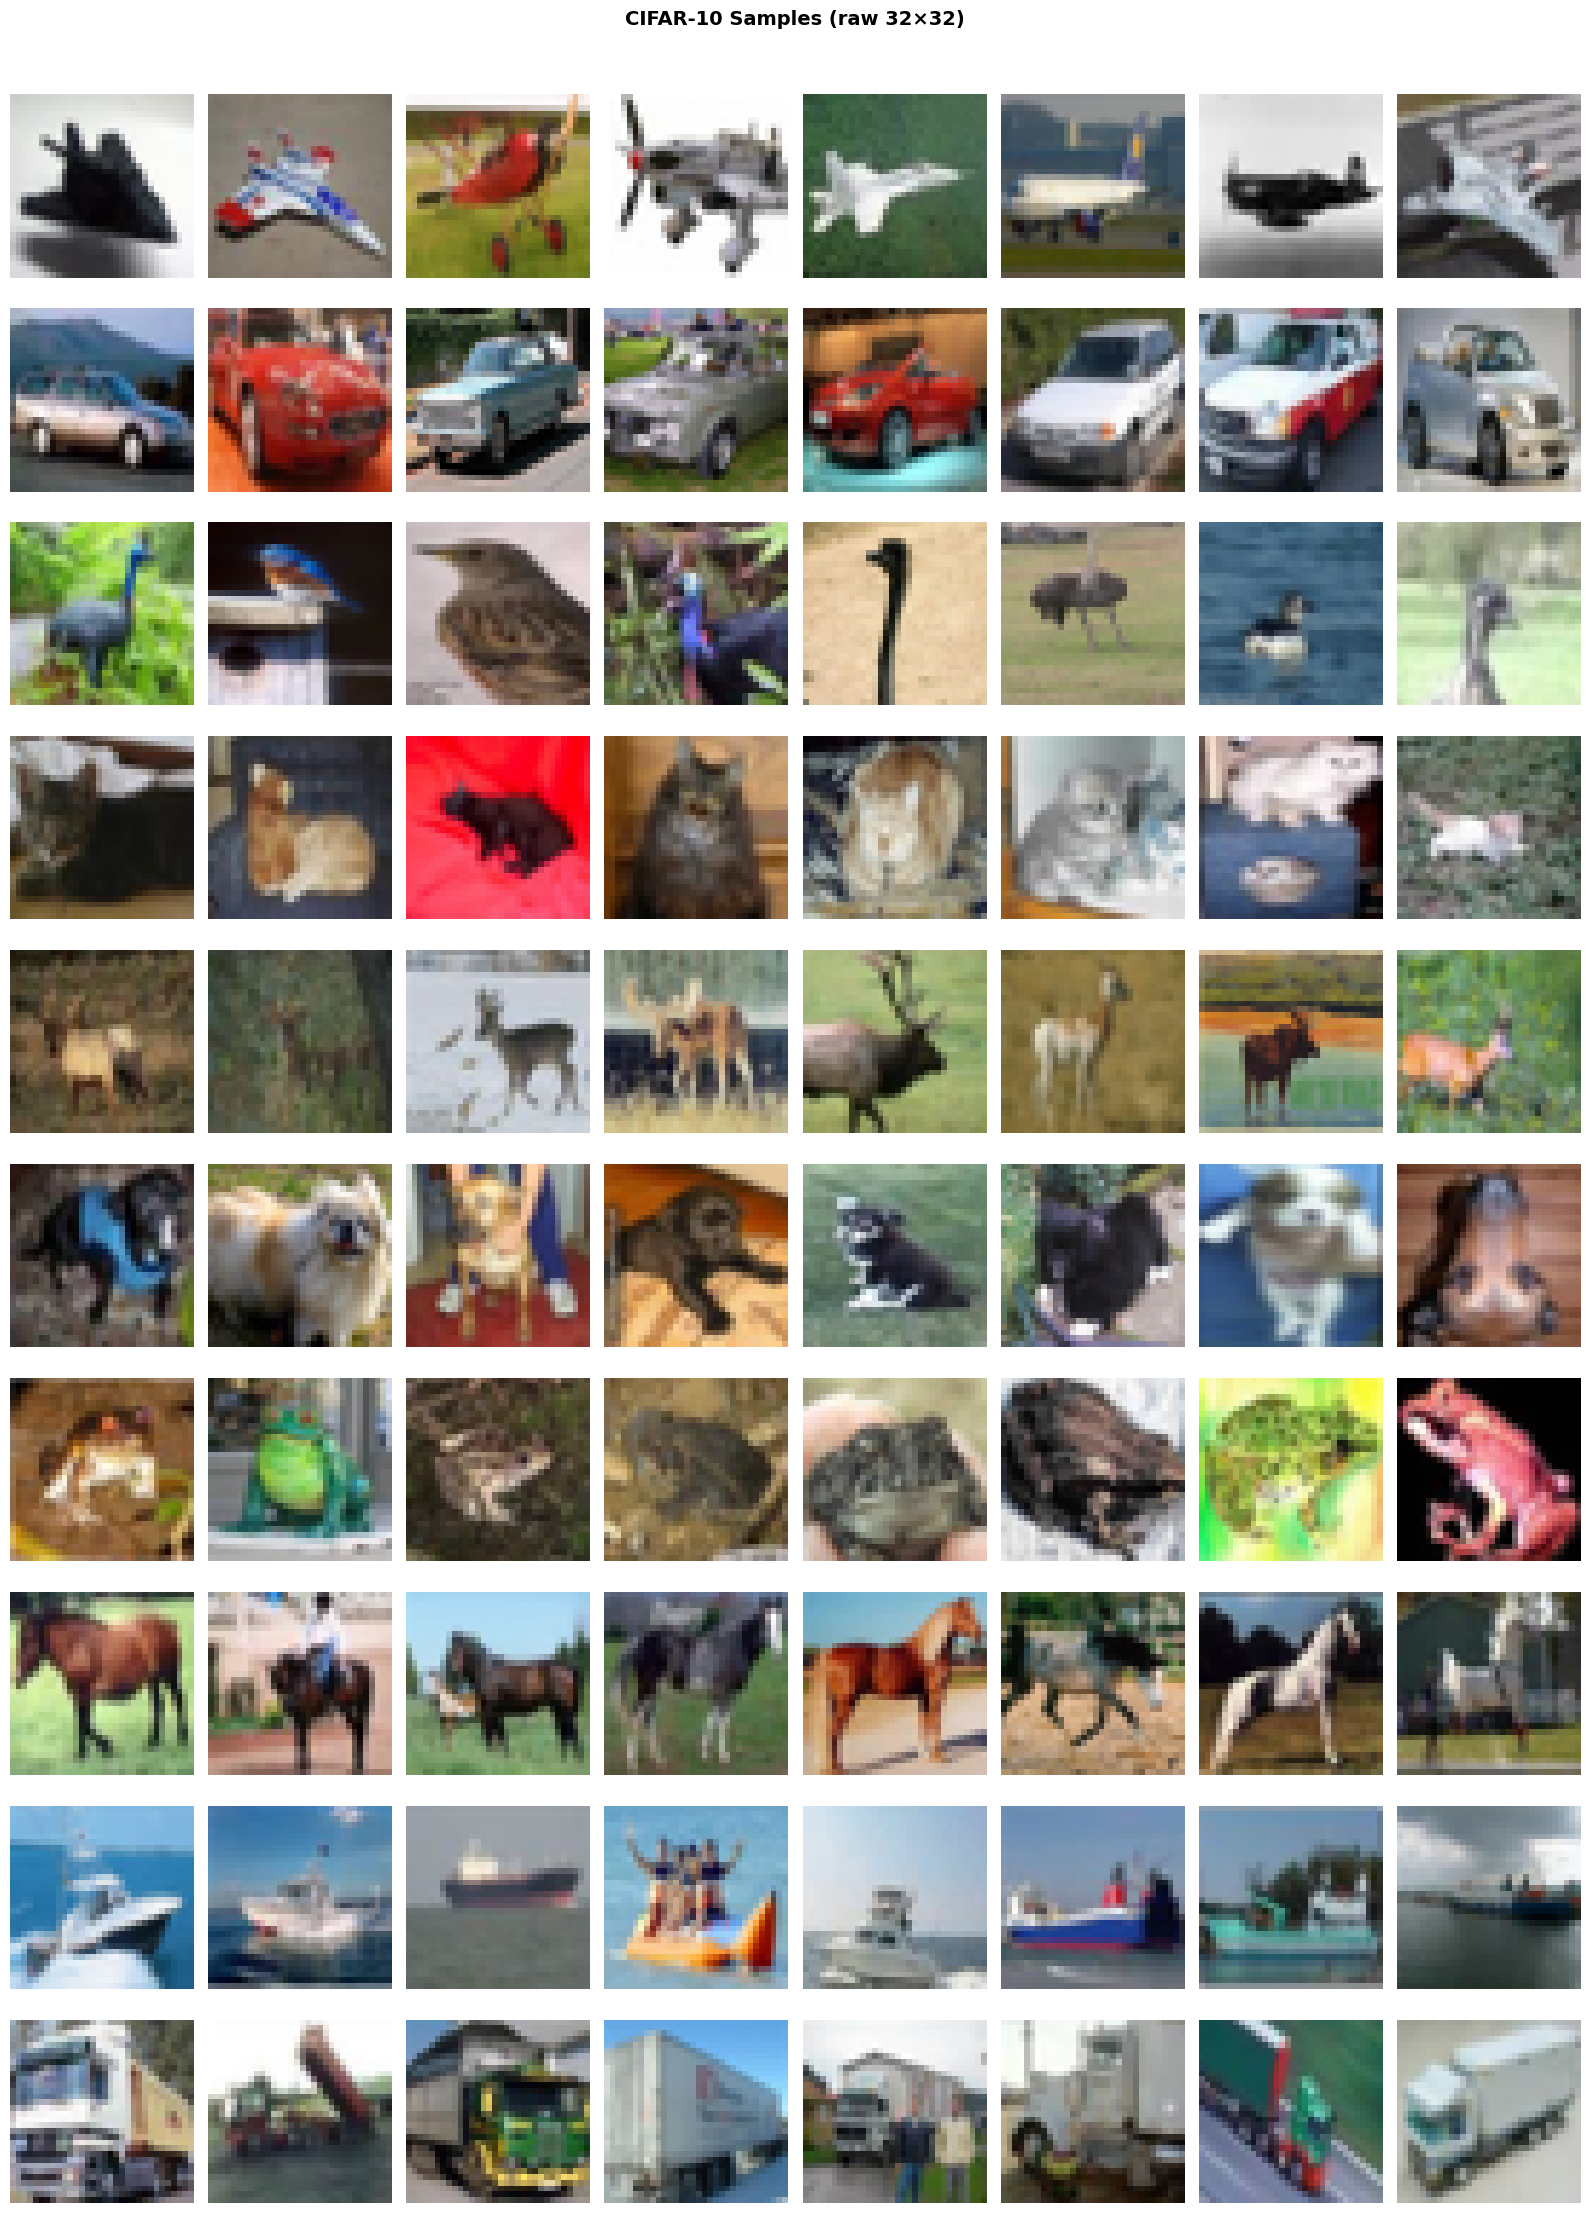

In [ ]:
# Sample grid — raw 32×32 images
fig, axes = plt.subplots(10, 8, figsize=(16, 22))
fig.suptitle('CIFAR-10 Samples (raw 32×32)', fontsize=14, fontweight='bold', y=1.01)

for row, cls_idx in enumerate(range(10)):
    idxs = np.where(labels_all == cls_idx)[0][:8]
    for col, idx in enumerate(idxs):
        img, _ = raw_ds[idx]
        axes[row][col].imshow(img.permute(1,2,0).numpy())
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(CLASS_NAMES[cls_idx].upper(), fontsize=9,
                            fontweight='bold', rotation=0, labelpad=55, va='center')

plt.tight_layout()
plt.savefig('/content/eda_samples.png', dpi=100, bbox_inches='tight')
plt.show()

# 🏗 Step 4: Build Model — EfficientNet-B0 + Custom Head

In [ ]:
class CIFAR10Classifier(nn.Module):
    """
    EfficientNetB0 (ImageNet pretrained) with custom classification head.
    - Backbone: ~5.3M params, pretrained on ImageNet-1k
    - Head: BN → Dropout → Linear(1280→256) → SiLU → Linear(256→10)
    """
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        weights       = EfficientNet_B0_Weights.IMAGENET1K_V1
        base          = efficientnet_b0(weights=weights)
        self.backbone = base.features          # Feature extractor
        self.pool     = base.avgpool           # AdaptiveAvgPool2d(1)
        in_features   = base.classifier[1].in_features  # 1280

        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.SiLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = x.flatten(1)
        return self.head(x)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


model = CIFAR10Classifier(num_classes=10).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  EfficientNetB0 loaded with ImageNet weights!')
print(f'  Total params    : {total:,}')
print(f'  Trainable params: {trainable:,}')

# Sanity check
with torch.no_grad():
    out = model(torch.randn(2,3,224,224).to(DEVICE))
    print(f'  Output shape    : {out.shape}   ')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 32.1MB/s]


  EfficientNetB0 loaded with ImageNet weights!
  Total params    : 4,341,126
  Trainable params: 4,341,126
  Output shape    : torch.Size([2, 10])   


# 🔥 Step 5: Two-Phase Training (Warmup → Fine-tune)

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler    = torch.cuda.amp.GradScaler()

def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    tot_loss = tot_correct = tot_n = 0
    for imgs, labels in tqdm(loader, desc='  train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        if scheduler: scheduler.step()
        tot_loss    += loss.item()
        tot_correct += (out.argmax(1) == labels).sum().item()
        tot_n       += labels.size(0)
    return tot_loss/len(loader), tot_correct/tot_n

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    tot_loss = tot_correct = tot_n = 0
    all_p, all_l, all_pr = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.cuda.amp.autocast():
            out  = model(imgs)
            loss = criterion(out, labels)
        probs = F.softmax(out, dim=1)
        tot_loss    += loss.item()
        tot_correct += (out.argmax(1) == labels).sum().item()
        tot_n       += labels.size(0)
        all_p.extend(out.argmax(1).cpu().numpy())
        all_l.extend(labels.cpu().numpy())
        all_pr.extend(probs.cpu().numpy())
    return (tot_loss/len(loader), tot_correct/tot_n,
            np.array(all_p), np.array(all_l), np.array(all_pr))


history   = {'tr_loss':[], 'tr_acc':[], 'vl_loss':[], 'vl_acc':[], 'lr':[]}
best_acc  = 0.0
BEST_PATH = '/content/best_model.pth'

# =====================================================
# PHASE 1 — Freeze backbone, train head only (5 epochs)
# =====================================================
PHASE1_EPOCHS = 5
print('='*58)
print(f'PHASE 1: Warmup — Head only ({PHASE1_EPOCHS} epochs)')
print('='*58)

model.freeze_backbone()
opt1 = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)
sch1 = OneCycleLR(opt1, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=PHASE1_EPOCHS)

t0 = time.time()
for ep in range(1, PHASE1_EPOCHS+1):
    tr_l, tr_a = train_epoch(model, train_loader, opt1, sch1)
    vl_l, vl_a, _, _, _ = eval_epoch(model, val_loader)
    history['tr_loss'].append(tr_l); history['tr_acc'].append(tr_a)
    history['vl_loss'].append(vl_l); history['vl_acc'].append(vl_a)
    history['lr'].append(opt1.param_groups[0]['lr'])
    star = ''
    if vl_a > best_acc:
        best_acc = vl_a; torch.save(model.state_dict(), BEST_PATH); star = ' ⭐'
    print(f'  Ep[{ep:02d}/{PHASE1_EPOCHS}] TrLoss:{tr_l:.4f} TrAcc:{tr_a:.4f} | VlLoss:{vl_l:.4f} VlAcc:{vl_a:.4f}{star}')

print(f'Phase 1 done in {(time.time()-t0)/60:.1f} min | Best: {best_acc*100:.2f}%')

# =====================================================
# PHASE 2 — Unfreeze all, fine-tune with differential LR
# =====================================================
PHASE2_EPOCHS = 15
print(f'\n{"+"*58}')
print(f'PHASE 2: Fine-tune all layers ({PHASE2_EPOCHS} epochs)')
print(f'{"+"*58}')

model.unfreeze_backbone()
opt2 = AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-4},
    {'params': model.pool.parameters(),     'lr': 1e-4},
    {'params': model.head.parameters(),     'lr': 5e-4}
], weight_decay=1e-4)
sch2 = OneCycleLR(opt2, max_lr=[1e-3, 1e-3, 5e-3],
                  steps_per_epoch=len(train_loader),
                  epochs=PHASE2_EPOCHS, pct_start=0.1)

t0 = time.time()
for ep in range(1, PHASE2_EPOCHS+1):
    tr_l, tr_a = train_epoch(model, train_loader, opt2, sch2)
    vl_l, vl_a, _, _, _ = eval_epoch(model, val_loader)
    history['tr_loss'].append(tr_l); history['tr_acc'].append(tr_a)
    history['vl_loss'].append(vl_l); history['vl_acc'].append(vl_a)
    history['lr'].append(opt2.param_groups[0]['lr'])
    star = ''
    if vl_a > best_acc:
        best_acc = vl_a; torch.save(model.state_dict(), BEST_PATH); star = '   '
    print(f'  Ep[{ep:02d}/{PHASE2_EPOCHS}] TrLoss:{tr_l:.4f} TrAcc:{tr_a:.4f} | VlLoss:{vl_l:.4f} VlAcc:{vl_a:.4f}{star}')

total_min = (time.time()-t0)/60
print(f'\n  Phase 2 done in {total_min:.1f} min | Best Val Acc: {best_acc*100:.2f}%')

PHASE 1: Warmup — Head only (5 epochs)


/tmp/ipykernel_950/2384563146.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()


  train:   0%|          | 0/352 [00:00<?, ?it/s]

/tmp/ipykernel_950/2384563146.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_950/2384563146.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Ep[01/5] TrLoss:1.4174 TrAcc:0.6070 | VlLoss:1.0316 VlAcc:0.7872 ⭐


...

  Ep[13/15] TrLoss:0.5074 TrAcc:0.9992 | VlLoss:0.5715 VlAcc:0.9732   


  train:   0%|          | 0/352 [00:00<?, ?it/s]

  Ep[14/15] TrLoss:0.5068 TrAcc:0.9996 | VlLoss:0.5702 VlAcc:0.9730


  train:   0%|          | 0/352 [00:00<?, ?it/s]

  Ep[15/15] TrLoss:0.5069 TrAcc:0.9995 | VlLoss:0.5703 VlAcc:0.9726

  Phase 2 done in 33.9 min | Best Val Acc: 97.32%


# 📈 Step 6: Training Curves

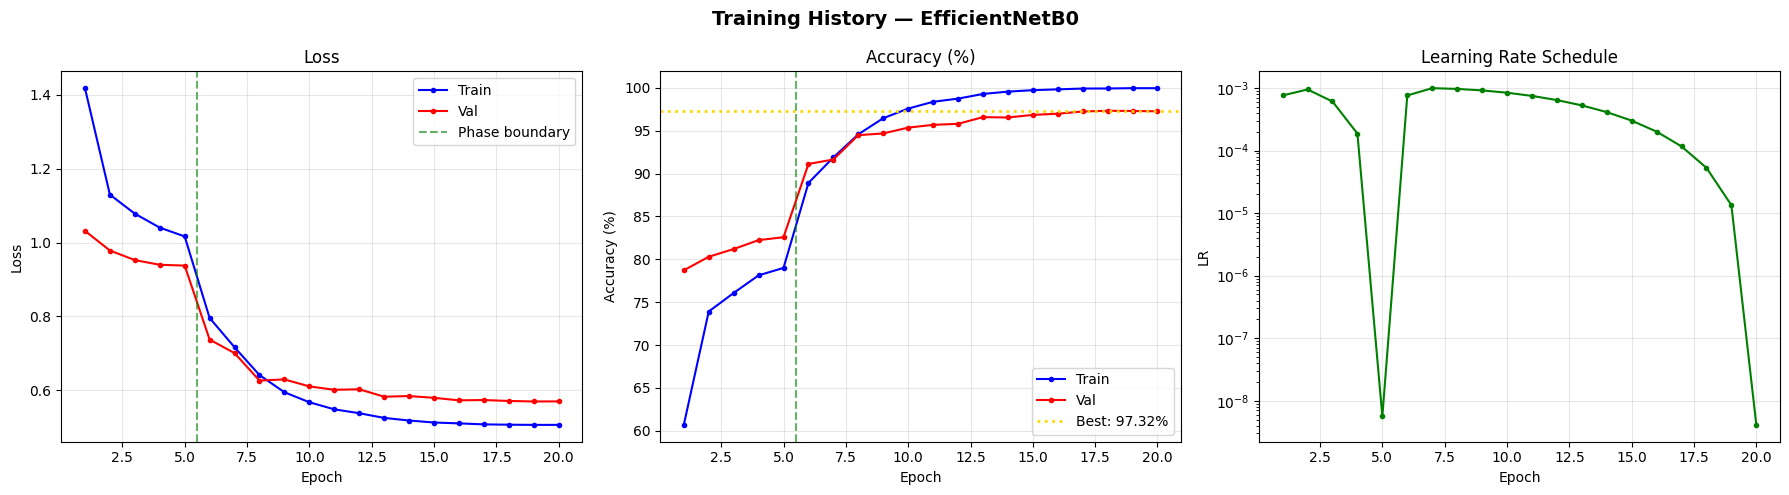

In [ ]:
total_eps = PHASE1_EPOCHS + PHASE2_EPOCHS
ep_range  = range(1, total_eps+1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — EfficientNetB0', fontsize=14, fontweight='bold')

axes[0].plot(ep_range, history['tr_loss'], 'b-o', ms=3, label='Train')
axes[0].plot(ep_range, history['vl_loss'], 'r-o', ms=3, label='Val')
axes[0].axvline(PHASE1_EPOCHS+0.5, color='green', ls='--', alpha=0.6, label='Phase boundary')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(ep_range, [a*100 for a in history['tr_acc']], 'b-o', ms=3, label='Train')
axes[1].plot(ep_range, [a*100 for a in history['vl_acc']], 'r-o', ms=3, label='Val')
axes[1].axvline(PHASE1_EPOCHS+0.5, color='green', ls='--', alpha=0.6)
axes[1].axhline(best_acc*100, color='gold', ls=':', lw=2, label=f'Best: {best_acc*100:.2f}%')
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')

axes[2].plot(ep_range, history['lr'], 'g-o', ms=3)
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')

plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150)
plt.show()

# 🎯 Step 7: Test Set Evaluation

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                               roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# Load best checkpoint
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))

_, test_acc, all_preds, all_labels, all_probs = eval_epoch(model, test_loader)
print(f'\n🎯 Final Test Accuracy: {test_acc*100:.2f}%')
print('\n' + classification_report(all_labels, all_preds,
                                    target_names=CLASS_NAMES, digits=4))

/tmp/ipykernel_950/2384563146.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



🎯 Final Test Accuracy: 96.82%

              precision    recall  f1-score   support

    airplane     0.9733    0.9840    0.9786      1000
  automobile     0.9637    0.9830    0.9733      1000
        bird     0.9806    0.9610    0.9707      1000
         cat     0.9395    0.9320    0.9357      1000
        deer     0.9625    0.9740    0.9682      1000
         dog     0.9419    0.9400    0.9409      1000
        frog     0.9879    0.9820    0.9850      1000
       horse     0.9723    0.9820    0.9771      1000
        ship     0.9810    0.9820    0.9815      1000
       truck     0.9796    0.9620    0.9707      1000

    accuracy                         0.9682     10000
   macro avg     0.9682    0.9682    0.9682     10000
weighted avg     0.9682    0.9682    0.9682     10000



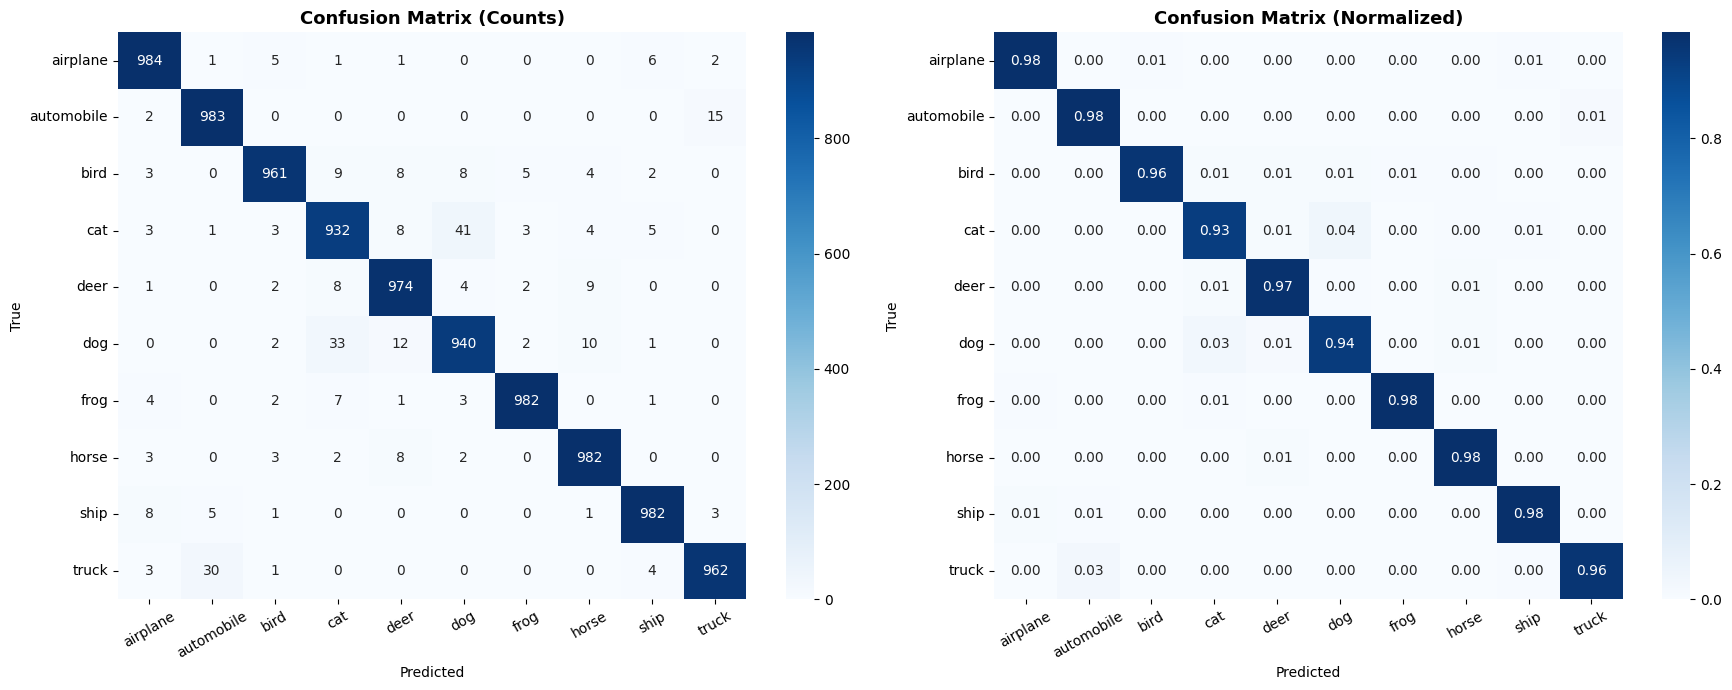

In [ ]:
# —— Confusion Matrix ————————————————————————
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

/tmp/ipykernel_950/2290365227.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')


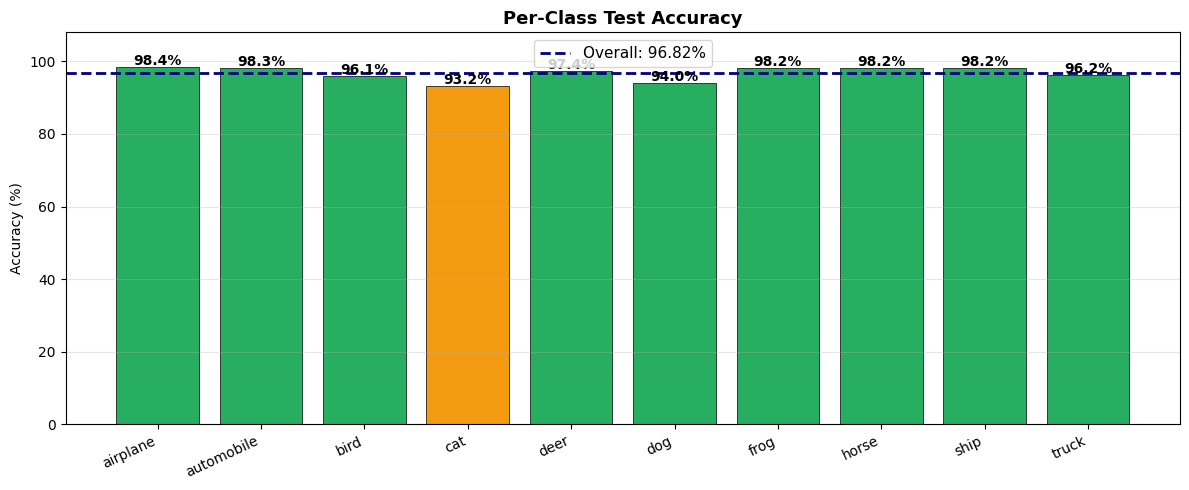

In [ ]:
# —— Per-class accuracy ——————————————————————
per_cls_acc = [(all_preds[all_labels==i]==i).mean()*100 for i in range(10)]

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['#27ae60' if a>=94 else '#f39c12' if a>=88 else '#e74c3c' for a in per_cls_acc]
bars = ax.bar(CLASS_NAMES, per_cls_acc, color=bar_colors, edgecolor='black', lw=0.5)
ax.axhline(test_acc*100, color='navy', ls='--', lw=2, label=f'Overall: {test_acc*100:.2f}%')
ax.set_ylim(0, 108); ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Test Accuracy', fontweight='bold', fontsize=13)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, per_cls_acc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/per_class_accuracy.png', dpi=150)
plt.show()

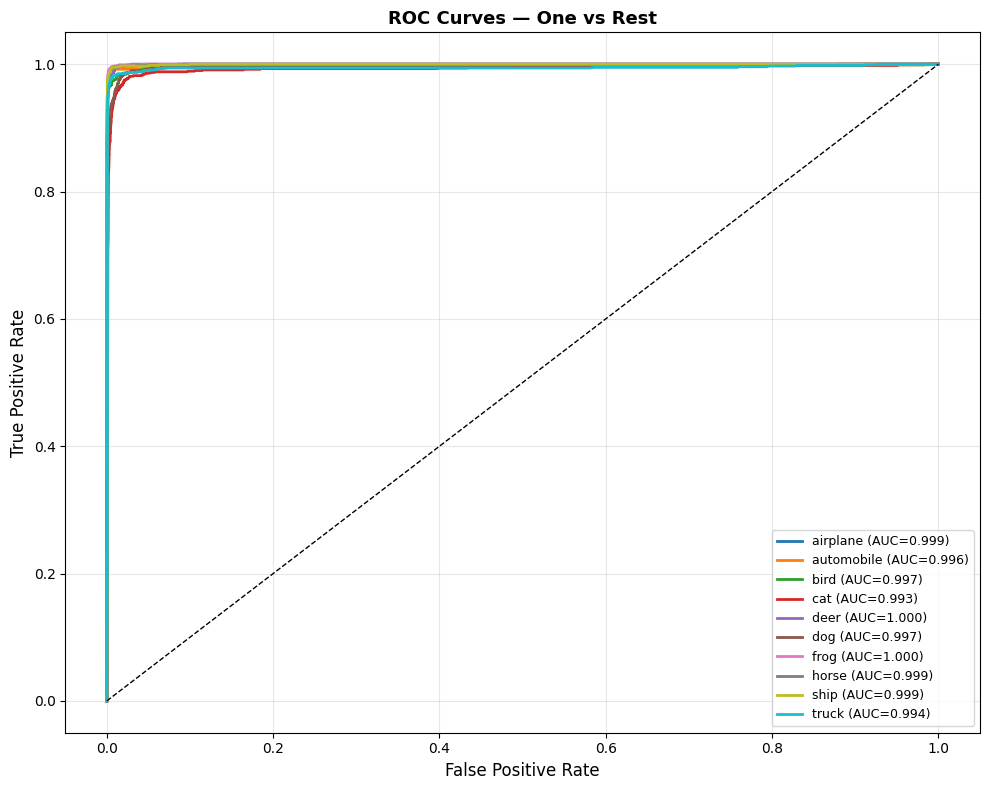

Macro ROC-AUC: 0.9974


In [ ]:
# —— ROC Curves ————————————————————————————
y_bin = label_binarize(all_labels, classes=list(range(10)))
colors_roc = plt.cm.tab10(np.linspace(0,1,10))

plt.figure(figsize=(10, 8))
auc_scores = []
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], all_probs[:,i])
    ra = auc(fpr, tpr); auc_scores.append(ra)
    plt.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={ra:.3f})')

plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — One vs Rest', fontweight='bold', fontsize=13)
plt.legend(fontsize=9, loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=150)
plt.show()

macro_auc = np.mean(auc_scores)
print(f'Macro ROC-AUC: {macro_auc:.4f}')

# 🔍 Step 8: Grad-CAM — Fixed & Working

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 46.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


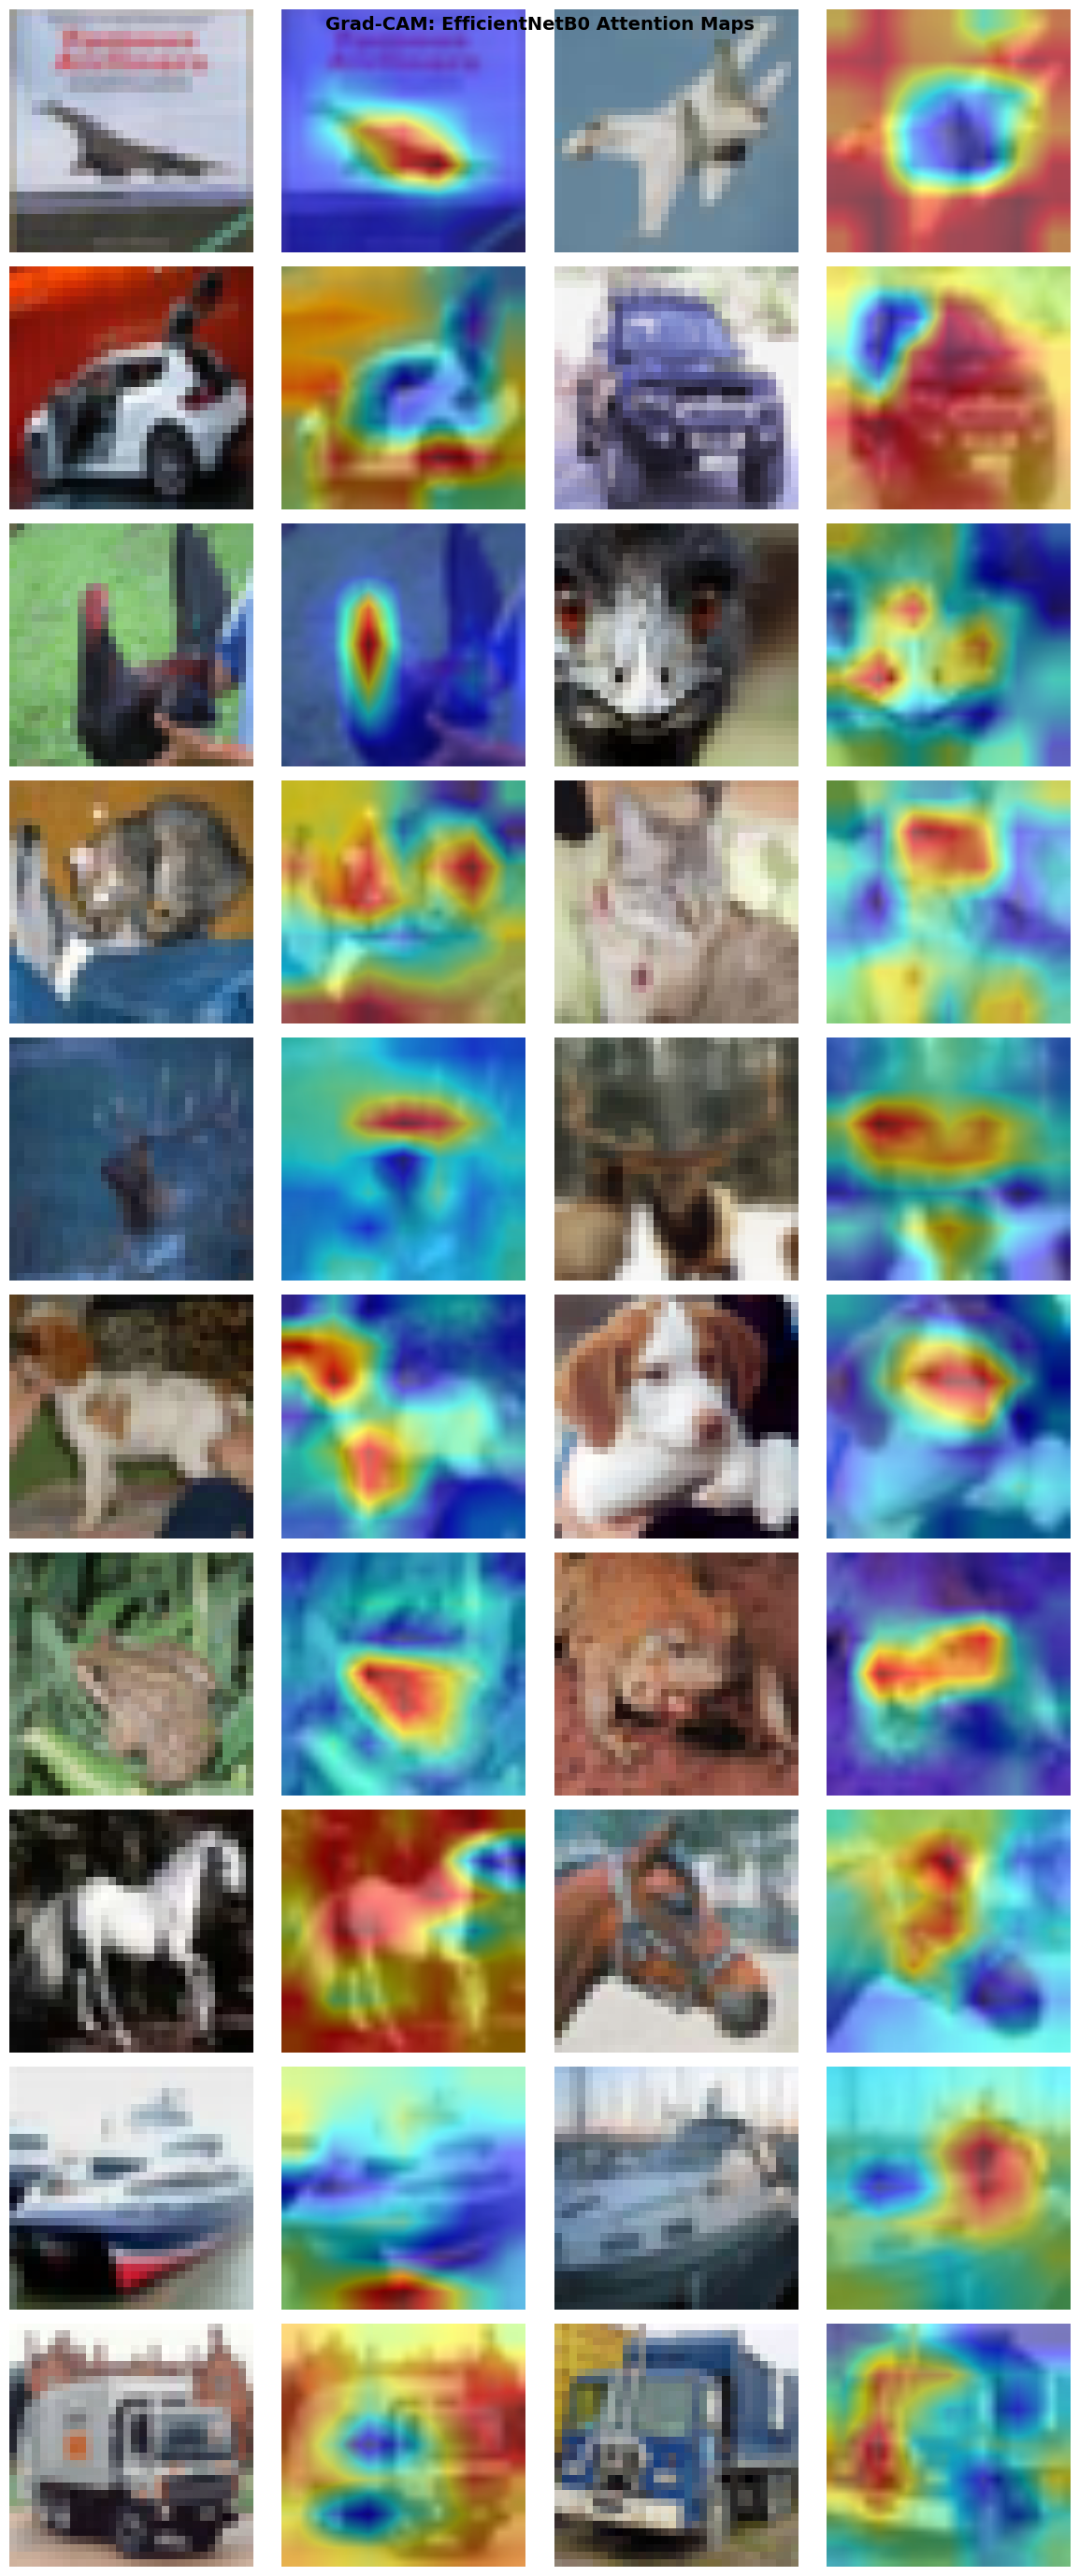

✅ Grad-CAM complete — no errors!


In [ ]:
# ✅ Install missing package
!pip install grad-cam -q

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ✅ FIX: Target the last conv block of EfficientNetB0 backbone
target_layers = [model.backbone[-1]]  # Last feature block
cam = GradCAM(model=model, target_layers=target_layers)

preprocess = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(MEAN, STD)
])

# Get test images directly from dataset
raw_test    = torchvision.datasets.CIFAR10('./data', train=False, download=False, transform=T.ToTensor())
test_targets = np.array(raw_test.targets)

fig, axes = plt.subplots(10, 4, figsize=(12, 28))
fig.suptitle('Grad-CAM: EfficientNetB0 Attention Maps', fontsize=14, fontweight='bold')

model.eval()
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_idxs = np.where(test_targets == cls_idx)[0][:2]
    for col_pair, img_idx in enumerate(cls_idxs):
        raw_img_tensor, _ = raw_test[img_idx]
        pil_img    = T.ToPILImage()(raw_img_tensor)
        np_img     = raw_img_tensor.permute(1,2,0).numpy()  # 32×32
        np_img_resized = np.array(
            pil_img.resize((224,224), Image.BILINEAR)
        ) / 255.0

        input_t = preprocess(pil_img).unsqueeze(0).to(DEVICE)
        input_t.requires_grad_(True)  # ✅ Ensure grad is tracked

        targets   = [ClassifierOutputTarget(cls_idx)]
        grayscale = cam(input_tensor=input_t, targets=targets)
        cam_img   = show_cam_on_image(
            np_img_resized.astype(np.float32), grayscale[0], use_rgb=True
        )

        axes[cls_idx][col_pair*2].imshow(np_img)   # Original 32×32
        axes[cls_idx][col_pair*2].axis('off')
        axes[cls_idx][col_pair*2+1].imshow(cam_img)  # Grad-CAM overlay
        axes[cls_idx][col_pair*2+1].axis('off')

    axes[cls_idx][0].set_ylabel(cls_name.upper(), fontsize=9,
                                fontweight='bold', rotation=0,
                                labelpad=50, va='center')

plt.tight_layout()
plt.savefig('/content/gradcam.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Grad-CAM complete — no errors!')

# 🔎 Step 9: Hard Sample Analysis

🔎 Top-10 Most Confused Pairs:
True             Predicted        Count
------------------------------------------
cat              dog              41
dog              cat              33
truck            automobile       30
automobile       truck            15
dog              deer             12
dog              horse            10
deer             horse            9
bird             cat              9
bird             dog              8
ship             airplane         8


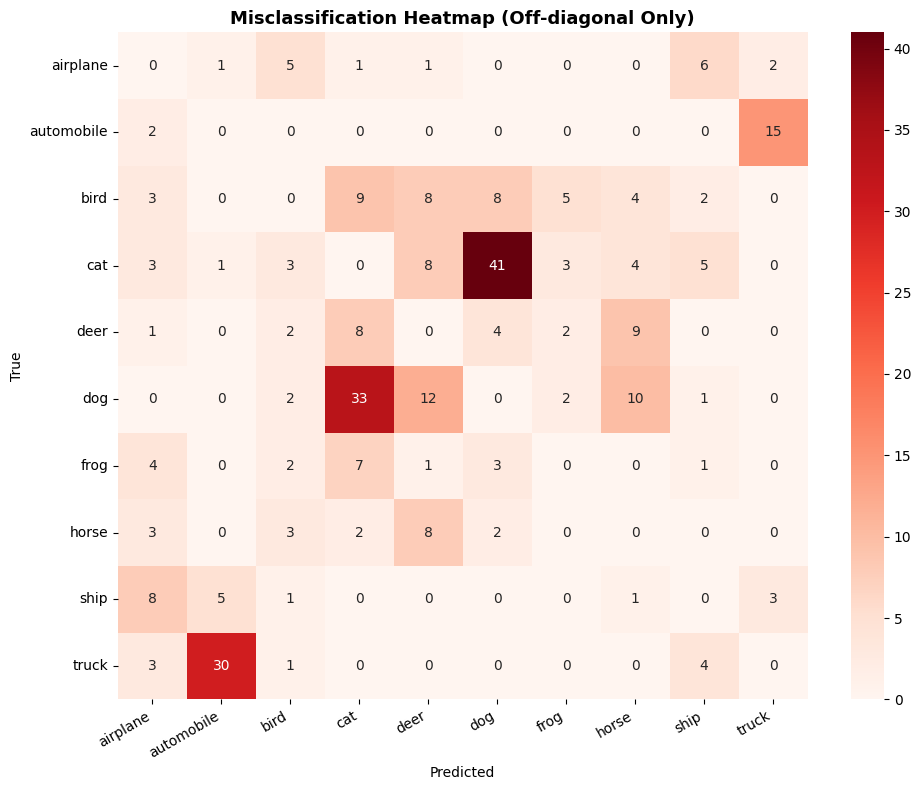

In [ ]:
from collections import Counter

wrong_mask = (all_preds != all_labels)
w_preds    = all_preds[wrong_mask]
w_labels   = all_labels[wrong_mask]
w_confs    = all_probs[wrong_mask].max(axis=1)

pairs = Counter(zip(w_labels, w_preds))
top10 = pairs.most_common(10)

print('🔎 Top-10 Most Confused Pairs:')
print(f'{"True":15s}  {"Predicted":15s}  Count')
print('-'*42)
for (t,p), c in top10:
    print(f'{CLASS_NAMES[t]:15s}  {CLASS_NAMES[p]:15s}  {c}')

# Misclassification heatmap
pair_mat = np.zeros((10,10), dtype=int)
for (t,p), c in pairs.items():
    pair_mat[t][p] = c
np.fill_diagonal(pair_mat, 0)

plt.figure(figsize=(10,8))
sns.heatmap(pair_mat, annot=True, fmt='d', cmap='Reds',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Misclassification Heatmap (Off-diagonal Only)', fontweight='bold', fontsize=13)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('/content/misclassification_heatmap.png', dpi=150)
plt.show()

# 💾 Step 10: Export Model

In [ ]:
!pip install onnxscript
model.eval()
dummy = torch.randn(1,3,224,224).to(DEVICE)

# ONNX
torch.onnx.export(model, dummy, '/content/cifar10_efficientnet.onnx',
                  opset_version=12, input_names=['image'], output_names=['logits'],
                  dynamic_axes={'image':{0:'batch'},'logits':{0:'batch'}})
print('  ✅ ONNX exported')

# TorchScript
ts = torch.jit.trace(model, dummy)
ts.save('/content/cifar10_efficientnet_ts.pt')
print('  ✅ TorchScript exported')

# Full checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names':      CLASS_NAMES,
    'test_accuracy':    test_acc,
    'macro_auc':        macro_auc,
    'img_mean':         MEAN, 'img_std': STD
}, '/content/cifar10_checkpoint.pth')
print('  ✅ Full checkpoint saved')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 17.1 MB/s eta 0:00:00


/tmp/ipykernel_950/2157598940.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(model, dummy, '/content/cifar10_efficientnet.onnx',
W0309 12:47:14.224000 950 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0309 12:47:16.021000 950 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scal

[torch.onnx] Obtain model graph for `CIFAR10Classifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CIFAR10Classifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

[torch.onnx] Translate the graph into ONNX... ✅
Applied 99 of general pattern rewrite rules.
  ✅ ONNX exported
  ✅ TorchScript exported
  ✅ Full checkpoint saved


# ☁️ Step 11: Save Model & Metadata to Google Drive

In [ ]:
# ============================================================
# Mount Google Drive and save all outputs + metadata
# ============================================================
from google.colab import drive
import shutil, json, datetime

drive.mount('/content/drive')

# —— Create project folder ——————————————————————
DRIVE_DIR = '/content/drive/MyDrive/CIFAR10_EfficientNetB0'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'📁 Drive folder: {DRIVE_DIR}')

# —— Build metadata dict ————————————————————————
from sklearn.metrics import precision_score, recall_score, f1_score

per_cls_metrics = {}
for i, cls in enumerate(CLASS_NAMES):
    mask = all_labels == i
    per_cls_metrics[cls] = {
        'accuracy':  float((all_preds[mask] == i).mean() * 100),
        'precision': float(precision_score(all_labels==i, all_preds==i)),
        'recall':    float(recall_score(all_labels==i, all_preds==i)),
        'f1':        float(f1_score(all_labels==i, all_preds==i)),
        'auc':       float(auc_scores[i])
    }

metadata = {
    'project':        'CIFAR-10 EfficientNetB0 Classifier',
    'saved_at':       datetime.datetime.now().isoformat(),
    'model': {
        'architecture': 'EfficientNetB0 + Custom Head',
        'total_params':     sum(p.numel() for p in model.parameters()),
        'trainable_params': sum(p.numel() for p in model.parameters() if p.requires_grad),
        'input_size':    [3, 224, 224],
        'num_classes':   NUM_CLASSES,
        'class_names':   CLASS_NAMES,
    },
    'training': {
        'batch_size':    BATCH_SIZE,
        'phase1_epochs': PHASE1_EPOCHS,
        'phase2_epochs': PHASE2_EPOCHS,
        'lr_head':       LR_HEAD,
        'lr_backbone':   LR_BACKBONE,
        'optimizer':     'AdamW',
        'scheduler':     'OneCycleLR',
        'loss':          'CrossEntropyLoss(label_smoothing=0.1)',
        'augmentation':  ['Resize(256)', 'RandomCrop(224)', 'RandomHorizontalFlip',
                          'RandAugment(2,7)', 'RandomErasing(0.2)'],
        'seed':          SEED,
        'history':       history,
    },
    'results': {
        'best_val_acc':     float(best_acc * 100),
        'test_accuracy':    float(test_acc * 100),
        'macro_roc_auc':    float(macro_auc),
        'per_class':        per_cls_metrics,
        'confusion_matrix': cm.tolist(),
    },
    'normalization': {
        'mean': list(MEAN),
        'std':  list(STD)
    },
    'files': {
        'checkpoint':   'cifar10_checkpoint.pth',
        'best_weights': 'best_model.pth',
        'onnx':         'cifar10_efficientnet.onnx',
        'torchscript':  'cifar10_efficientnet_ts.pt',
        'metadata':     'metadata.json',
    }
}

# —— Save metadata JSON ————————————————————————
meta_path = f'{DRIVE_DIR}/metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print('  ✅ metadata.json saved')

# —— Copy model files ————————————————————————
files_to_copy = [
    ('/content/cifar10_checkpoint.pth',    'cifar10_checkpoint.pth'),
    ('/content/best_model.pth',            'best_model.pth'),
    ('/content/cifar10_efficientnet.onnx', 'cifar10_efficientnet.onnx'),
    ('/content/cifar10_efficientnet_ts.pt','cifar10_efficientnet_ts.pt'),
]

for src, dst_name in files_to_copy:
    dst = f'{DRIVE_DIR}/{dst_name}'
    if os.path.exists(src):
        shutil.copy2(src, dst)
        size_mb = os.path.getsize(dst) / 1e6
        print(f'  ✅ {dst_name} ({size_mb:.1f} MB)')
    else:
        print(f'  ⚠️  {src} not found — skipping')

# —— Copy plots ——————————————————————————————
plots_dir = f'{DRIVE_DIR}/plots'
os.makedirs(plots_dir, exist_ok=True)

plot_files = [
    '/content/training_history.png',
    '/content/confusion_matrix.png',
    '/content/per_class_accuracy.png',
    '/content/roc_curves.png',
    '/content/gradcam.png',
    '/content/misclassification_heatmap.png',
    '/content/eda_distribution.png',
    '/content/eda_samples.png',
]

for pf in plot_files:
    if os.path.exists(pf):
        shutil.copy2(pf, f"{plots_dir}/{os.path.basename(pf)}")
        print(f'  📊 {os.path.basename(pf)} saved')

print(f'\n🎉 All files saved to Google Drive: {DRIVE_DIR}')
print(f'   Test Accuracy : {test_acc*100:.2f}%')
print(f'   Macro ROC-AUC : {macro_auc:.4f}')
print(f'   Best Val Acc  : {best_acc*100:.2f}%')

Mounted at /content/drive
📁 Drive folder: /content/drive/MyDrive/CIFAR10_EfficientNetB0
  ✅ metadata.json saved
  ✅ cifar10_checkpoint.pth (17.7 MB)
  ✅ best_model.pth (17.7 MB)
  ✅ cifar10_efficientnet.onnx (0.6 MB)
  ✅ cifar10_efficientnet_ts.pt (18.2 MB)
  📊 training_history.png saved
  📊 confusion_matrix.png saved
  📊 per_class_accuracy.png saved
  📊 roc_curves.png saved
  📊 gradcam.png saved
  📊 misclassification_heatmap.png saved
  📊 eda_distribution.png saved
  📊 eda_samples.png saved

🎉 All files saved to Google Drive: /content/drive/MyDrive/CIFAR10_EfficientNetB0
   Test Accuracy : 96.82%
   Macro ROC-AUC : 0.9974
   Best Val Acc  : 97.32%


# 📋 Step 12: Final Report

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, cohen_kappa_score

precision  = precision_score(all_labels, all_preds, average='weighted')
recall_val = recall_score(all_labels, all_preds, average='weighted')
f1         = f1_score(all_labels, all_preds, average='weighted')
kappa      = cohen_kappa_score(all_labels, all_preds)

print('='*58)
print('        CIFAR-10 EfficientNetB0 — Final Report')
print('='*58)
print(f'  Test Accuracy        : {test_acc*100:.2f}%')
print(f'  Weighted Precision   : {precision*100:.2f}%')
print(f'  Weighted Recall      : {recall_val*100:.2f}%')
print(f'  Weighted F1-Score    : {f1*100:.2f}%')
print(f'  Cohen Kappa          : {kappa:.4f}')
print(f'  Macro ROC-AUC        : {macro_auc:.4f}')
print(f'  Best Val Accuracy    : {best_acc*100:.2f}%')
print('='*58)
print('\nPer-class accuracy:')
for cls, acc in zip(CLASS_NAMES, per_cls_acc):
    bar = '█' * int(acc/2) + '░' * (50-int(acc/2))
    print(f'  {cls:12s} {acc:5.1f}%  |{bar}|')
print('='*58)

        CIFAR-10 EfficientNetB0 — Final Report
  Test Accuracy        : 96.82%
  Weighted Precision   : 96.82%
  Weighted Recall      : 96.82%
  Weighted F1-Score    : 96.82%
  Cohen Kappa          : 0.9647
  Macro ROC-AUC        : 0.9974
  Best Val Accuracy    : 97.32%

Per-class accuracy:
  airplane      98.4%  |█████████████████████████████████████████████████░|
  automobile    98.3%  |█████████████████████████████████████████████████░|
  bird          96.1%  |████████████████████████████████████████████████░░|
  cat           93.2%  |██████████████████████████████████████████████░░░░|
  deer          97.4%  |████████████████████████████████████████████████░░|
  dog           94.0%  |███████████████████████████████████████████████░░░|
  frog          98.2%  |█████████████████████████████████████████████████░|
  horse         98.2%  |█████████████████████████████████████████████████░|
  ship          98.2%  |█████████████████████████████████████████████████░|
  truck         96.2%  |

# 🖥️ Step 13: Interactive Inference UI
> Run this cell to launch an interactive widget for single-image prediction with Grad-CAM overlay.
> Upload any image (JPEG/PNG) or pick a random test sample.

In [1]:
!pip install grad-cam -q
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights
import torchvision.transforms as T
import torchvision
import numpy as np
import random
import matplotlib.pyplot as plt
import torch.nn.functional as F
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import io
from PIL import Image as PILImage
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

class CIFAR10Classifier(nn.Module):
    def __init__(self, num_classes=10, dropout=0.4):
        super().__init__()
        weights        = EfficientNet_B0_Weights.IMAGENET1K_V1
        base           = models.efficientnet_b0(weights=weights)
        self.backbone  = base.features
        self.pool      = base.avgpool
        in_features    = base.classifier[1].in_features

        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.SiLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = x.flatten(1)
        return self.head(x)

model = CIFAR10Classifier(num_classes=10).to(DEVICE)

MODEL_PATH = '/content/drive/MyDrive/CIFAR10_EfficientNetB0/best_model.pth'
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
elif isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
else:
    state_dict = checkpoint

model.load_state_dict(state_dict)
model.eval()
print(f"✅ Model loaded! Device: {DEVICE}")

target_layers = [model.backbone[-1]]
cam = GradCAM(model=model, target_layers=target_layers)
print("✅ GradCAM ready!")

preprocess = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

raw_test = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True,
    transform=T.ToTensor()
)
test_targets = np.array(raw_test.targets)
print(f"✅ Test set: {len(raw_test)} samples")

# ══════════════════════════════════════════════════════════
# UI
# ══════════════════════════════════════════════════════════
title_html = widgets.HTML(value="""
    <div style='background:linear-gradient(135deg,#1a1a2e,#16213e,#0f3460);
                padding:18px 24px; border-radius:12px; margin-bottom:12px;'>
      <h2 style='color:#e94560; font-family:monospace; margin:0;'>
        ⚡ CIFAR-10 · EfficientNetB0 · Live Inference
      </h2>
      <p style='color:#a8b2d8; font-size:13px; margin:6px 0 0 0;'>
        Upload an image or pick a random test sample to classify
      </p>
    </div>""")

upload_btn  = widgets.FileUpload(accept='image/*', multiple=False,
                                 description='📤 Upload Image',
                                 layout=widgets.Layout(width='200px'))
random_btn  = widgets.Button(description='🎲 Random Sample',
                              button_style='info',
                              layout=widgets.Layout(width='180px', height='36px'))
class_dd    = widgets.Dropdown(options=['(any)'] + CLASS_NAMES,
                               description='Class filter:',
                               layout=widgets.Layout(width='220px'))
gradcam_tog = widgets.ToggleButton(value=True, description='Show Grad-CAM',
                                   button_style='warning',
                                   layout=widgets.Layout(width='160px'))
out         = widgets.Output()
history_out = widgets.Output()

def run_inference(pil_img, true_label=None):
    with out:
        clear_output(wait=True)


        pil_img = pil_img.resize((224, 224), PILImage.BILINEAR)

        img_tensor = preprocess(pil_img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = model(img_tensor)
            probs  = F.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred_idx  = int(np.argmax(probs))
        pred_name = CLASS_NAMES[pred_idx]
        conf      = probs[pred_idx] * 100


        np_img_disp = np.array(pil_img) / 255.0
        np_img_disp = np_img_disp.astype(np.float32)

        ncols = 3 if gradcam_tog.value else 2
        fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 5), facecolor='#1a1a2e')
        fig.patch.set_facecolor('#1a1a2e')

        axes[0].imshow(np_img_disp)
        axes[0].axis('off')
        title0 = 'Input Image'
        if true_label is not None:
            title0 += f'\nTrue: {CLASS_NAMES[true_label]}'
        axes[0].set_title(title0, color='white', fontsize=12, fontweight='bold')

        bar_colors = ['#e94560' if i == pred_idx else '#4a90d9' for i in range(10)]
        axes[1].barh(CLASS_NAMES, probs * 100, color=bar_colors, edgecolor='none')
        axes[1].set_xlim(0, 110)
        axes[1].set_facecolor('#16213e')
        axes[1].tick_params(colors='white')
        for spine in axes[1].spines.values(): spine.set_color('#334')
        axes[1].set_xlabel('Confidence (%)', color='#a8b2d8')
        for i, p in enumerate(probs * 100):
            axes[1].text(p + 1.5, i, f'{p:.1f}%', va='center',
                         color='white', fontsize=9, fontweight='bold')
        correct_str = ''
        if true_label is not None:
            correct_str = ' ✅' if pred_idx == true_label else ' ❌'
        axes[1].set_title(f'Prediction: {pred_name.upper()}{correct_str}\nConf: {conf:.1f}%',
                          color='#e94560', fontsize=12, fontweight='bold')

        if gradcam_tog.value:
            img_tensor_gc = preprocess(pil_img).unsqueeze(0).to(DEVICE)
            img_tensor_gc.requires_grad_(True)
            targets_gc  = [ClassifierOutputTarget(pred_idx)]
            grayscale   = cam(input_tensor=img_tensor_gc, targets=targets_gc)
            cam_overlay = show_cam_on_image(np_img_disp, grayscale[0], use_rgb=True)
            axes[2].imshow(cam_overlay)
            axes[2].axis('off')
            axes[2].set_title('Grad-CAM Attention', color='white', fontsize=12, fontweight='bold')

        plt.tight_layout(pad=1.5)
        plt.show()

        color = '#2ecc71' if (true_label is None or pred_idx == true_label) else '#e74c3c'
        label_line = ''
        if true_label is not None:
            label_line = f"<b>True Label :</b> {CLASS_NAMES[true_label]}<br>"
        display(HTML(f"""
        <div style='background:#16213e; border-left:4px solid {color};
                    padding:12px 18px; border-radius:8px; font-family:monospace;
                    color:#cdd6f4; margin-top:8px;'>
          {label_line}
          <b>Prediction :</b> <span style='color:{color};font-size:15px;'>{pred_name.upper()}</span><br>
          <b>Confidence :</b> {conf:.2f}%<br>
          <b>Top-3      :</b> {', '.join([f"{CLASS_NAMES[i]} ({probs[i]*100:.1f}%)" for i in np.argsort(probs)[::-1][:3]])}
        </div>"""))

    with history_out:
        color = '#2ecc71' if (true_label is None or pred_idx == true_label) else '#e74c3c'
        label_line = f"<b>True:</b> {CLASS_NAMES[true_label]} | " if true_label is not None else ""
        correct_str = (' ✅' if pred_idx == true_label else ' ❌') if true_label is not None else ''
        display(HTML(f"""
        <div style='background:#0d1117; border-left:3px solid {color};
                    padding:6px 14px; border-radius:6px; font-family:monospace;
                    color:#a8b2d8; font-size:12px; margin:4px 0;'>
          {label_line}
          <b>Pred:</b> <span style='color:{color};'>{pred_name.upper()}{correct_str}</span> |
          <b>Conf:</b> {conf:.1f}% |
          <b>Top-3:</b> {', '.join([f"{CLASS_NAMES[i]}({probs[i]*100:.0f}%)" for i in np.argsort(probs)[::-1][:3]])}
        </div>"""))

def on_upload(change):
    if upload_btn.value:
        uploaded  = list(upload_btn.value.values())[0]
        img_bytes = uploaded['content'] if isinstance(uploaded, dict) else bytes(uploaded)
        pil = PILImage.open(io.BytesIO(img_bytes)).convert('RGB')
        run_inference(pil, true_label=None)

def on_random(b):
    chosen_class = class_dd.value
    if chosen_class == '(any)':
        idx = random.randint(0, len(raw_test)-1)
    else:
        cls_i      = CLASS_NAMES.index(chosen_class)
        candidates = np.where(test_targets == cls_i)[0]
        idx        = int(np.random.choice(candidates))
    img_t, true_lbl = raw_test[idx]
    pil = T.ToPILImage()(img_t)
    run_inference(pil, true_label=true_lbl)

upload_btn.observe(on_upload, names='value')
random_btn.on_click(on_random)

controls = widgets.HBox([upload_btn, random_btn, class_dd, gradcam_tog],
                         layout=widgets.Layout(gap='12px', flex_wrap='wrap', padding='8px'))
history_header = widgets.HTML(
    "<div style='color:#a8b2d8; font-family:monospace; font-size:12px; "
    "padding:6px 0; border-bottom:1px solid #334; margin-top:16px;'>"
    "📋 Previous Results</div>")

display(title_html, controls, out, history_header, history_out)
on_random(None)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 113.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Mounted at /content/drive
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 56.2MB/s]


✅ Model loaded! Device: cuda
✅ GradCAM ready!


100%|██████████| 170M/170M [00:19<00:00, 8.93MB/s]


✅ Test set: 10000 samples


HTML(value="\n    <div style='background:linear-gradient(135deg,#1a1a2e,#16213e,#0f3460);\n                pad…

Output()

HTML(value="<div style='color:#a8b2d8; font-family:monospace; font-size:12px; padding:6px 0; border-bottom:1px…

Output()